In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
sns.set_theme(style='whitegrid')
df = pd.read_csv('olist_cleaned.csv')
df['order_purchase_timestamp'] =pd.to_datetime(df['order_purchase_timestamp'])
print(df.shape)

(118301, 19)


In [3]:
#RFM Model
#Identify current time of this data
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

#Calculate R (Recency), F (Frequency), M (Monetary) of each unique customer
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, #Recency
    'order_id':'nunique', #Frequency
    'payment_value': 'sum' #Monetary
}).reset_index()
#Rename these columns
rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']
#Allocate grades from 1 to 5 using Quantiles
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]) #The smaller R is, the higher the R score is
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels =[1,2,3,4,5]) #The higher M is, the higher the M score is
rfm['F_score'] = rfm['Frequency'].apply(lambda x:1 if x==1 else (3 if x==2 else 5))

#Group customer segments based on their scores
def segment_customer(df):
    r = df['R_score']
    f = df['F_score']
    m = df['M_score']

    if r >=4 and f == 5:
        return 'Champions (VIP)'
    elif r >=3 and f >=3:
        return 'Loyal Customers'
    elif r>=4 and f==1 and m>=4:
        return 'Promising Potential Customers'
    elif r >=4 and f==1:
        return 'New Customers'
    elif r<=2 and f ==1 and m>=4:
        return 'Important, Almost Leaving Customers'
    elif r <=2 and f==1 and m<=2:
        return 'Hibernating Customers'
    else:
        return 'About-to-Sleep Customers'
rfm['Segment'] = rfm.apply(segment_customer, axis = 1)

segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts['Percentage'] = round((segment_counts['count']/segment_counts['count'].sum()) * 100, 2)
print(segment_counts)
    

                               Segment  count  Percentage
0             About-to-Sleep Customers  26910       28.20
1                        New Customers  22275       23.34
2                Hibernating Customers  15554       16.30
3        Promising Potential Customers  14653       15.36
4  Important, Almost Leaving Customers  14145       14.82
5                      Loyal Customers   1750        1.83
6                      Champions (VIP)    131        0.14


<Figure size 1200x1000 with 0 Axes>

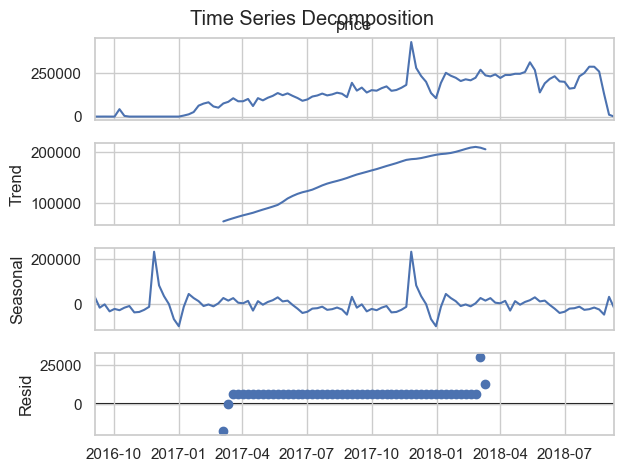

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

#Prep time series data
timeline_df = df[~df['order_status'].isin(['canceled', 'unavailable'])]
    #Cluster into Weeks. Use price because it reflects customer's demands on time, not shipping prices, to see the tendency to grow of products
ts_data = timeline_df.set_index('order_purchase_timestamp').resample('W')['price'].sum().to_frame()

#2. Decompose time series into: Trend, Seasonal, and Residual
#Assume cycle is 52 weeks (1 year)
decomposition = seasonal_decompose(ts_data['price'], model = 'additive', period = 52)

#3. Draw graphs
plt.figure(figsize = (12,10))
decomposition.plot()
plt.suptitle('Time Series Decomposition')
plt.savefig('time_series_decomposition.png', bbox_inches = 'tight')
plt.show()

In [5]:
from mlxtend.frequent_patterns import apriori, association_rules
#product basket
basket = (df[~df['order_status'].isin(['canceled', 'unavailable'])].groupby(['order_id', 'product_category_english'])['product_id'].count().unstack().reset_index().fillna(0).set_index('order_id'))
#calc if it appears then 1, else 0
def encode_units(x):
    if x<=0:
        return False
    if x>=1:
        return True
basket_sets = basket.map(encode_units)
#Find group of product categories that appear together
frequent_itemsets = apriori(basket_sets, min_support = 0.0005, use_colnames = True)
#Calc Support, Confidence, and Lift
rules = association_rules(frequent_itemsets, metric = 'lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending = False).reset_index(drop=True)
#show most common 10 bought together
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


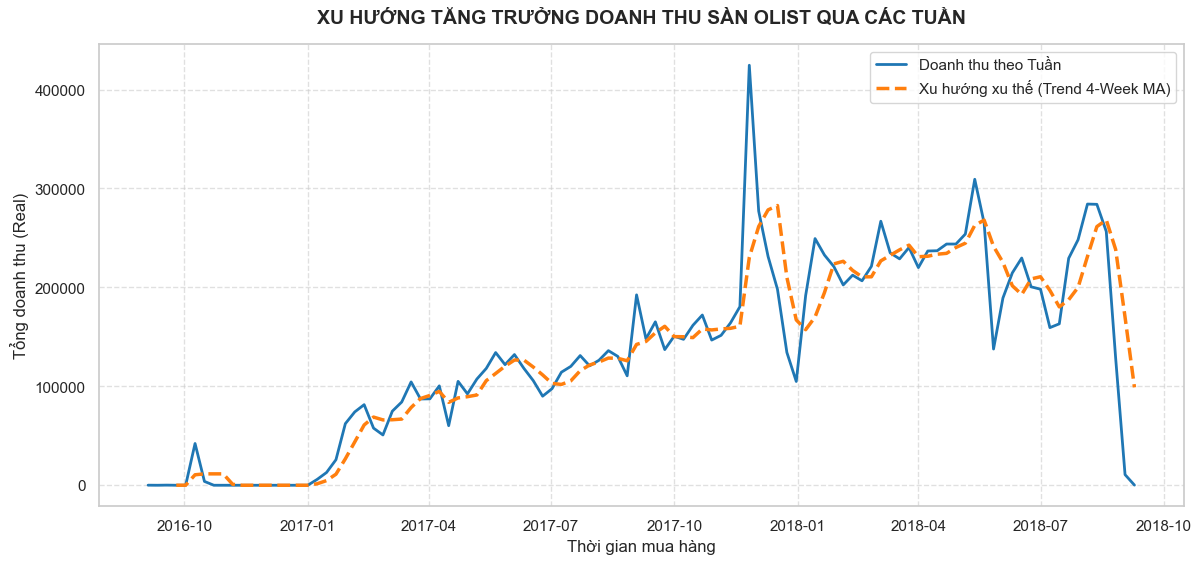

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gom dữ liệu theo tuần (như đã giải thích ở phần trước)
ts_weekly = df[~df['order_status'].isin(['canceled', 'unavailable'])].set_index('order_purchase_timestamp').resample('W')['price'].sum().reset_index()

# 2. Vẽ biểu đồ xu hướng doanh thu
plt.figure(figsize=(14, 6))
sns.lineplot(data=ts_weekly, x='order_purchase_timestamp', y='price', color='#1f77b4', linewidth=2, label='Doanh thu theo Tuần')

# Tính đường trung bình động (Rolling Average) 4 tuần để thấy xu hướng mượt mà, không bị nhiễu
ts_weekly['Rolling_Mean'] = ts_weekly['price'].rolling(window=4).mean()
sns.lineplot(data=ts_weekly, x='order_purchase_timestamp', y='Rolling_Mean', color='#ff7f0e', linewidth=2.5, linestyle='--', label='Xu hướng xu thế (Trend 4-Week MA)')

plt.title('XU HƯỚNG TĂNG TRƯỞNG DOANH THU SÀN OLIST QUA CÁC TUẦN', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thời gian mua hàng', fontsize=12)
plt.ylabel('Tổng doanh thu (Real)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Lưu ảnh chất lượng cao để chèn vào Slide/Report
plt.savefig('olist_revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()

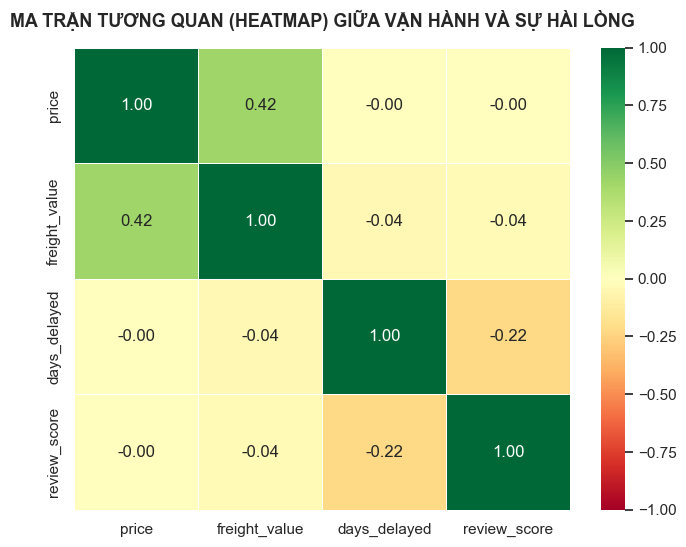

In [7]:
# 1. Chọn ra các cột số quan trọng cần đo lường mối tương quan
correlation_matrix = df[['price', 'freight_value', 'days_delayed', 'review_score']].corr()

# 2. Vẽ biểu đồ nhiệt Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('MA TRẬN TƯƠNG QUAN (HEATMAP) GIỮA VẬN HÀNH VÀ SỰ HÀI LÒNG', fontsize=13, fontweight='bold', pad=15)
plt.savefig('olist_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# 2. Filter necessary columns


# 3.  Downcast to reduce RAM usage
df['payment_installments'] = df['payment_installments'].fillna(0).astype('int8')
df['review_score'] = df['review_score'].fillna(0).astype('int8')

df['price'] = df['price'].astype('float32')
df['freight_value'] = df['freight_value'].astype('float32')

# 4. Use YYYY-MM-ĐD standard
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp']).dt.date

# 5. Pre-binning for drill down
# A: For Installments
def bin_installments(x):
    if x == 1: 
        return '1. Immediate Payment'
    elif 2 <= x <= 5: 
        return '2. Short Installments (2-5 periods)'
    else: 
        return '3. Long Installments (6-10+ periods)'

df['Installment_Group'] = df['payment_installments'].apply(bin_installments)

# B: Product Group
durable_categories = [
    'bed_bath_table', 'furniture_decor', 'housewares', 
    'watches_gifts', 'auto', 'office_furniture', 'cool_stuff'
]

def bin_product_group(cat):
    if pd.isna(cat):
        return 'Unknown'
    elif str(cat).lower() in durable_categories:
        return 'Durable Goods (Long-time Usage)'
    else:
        return 'Consumable & Lifestyle (Trend/Daily Usage)'

df['Product_Group'] = df['product_category_english'].apply(bin_product_group)

# C: Delivery Status
def bin_delivery(days):
    if pd.isna(days) or days <= 0:
        return '1. On Time/ Early'
    else:
        return '2. Delayed Delivery'

df['Delivery_Status'] = df['days_delayed'].apply(bin_delivery)

# 6. TURN INTO CSV
df.to_csv('olist_for_powerbi.csv', index=False)
print("🎉 Done")

🎉 Done


In [9]:
order_counts = df.groupby('customer_unique_id')['order_id'].nunique()
print(order_counts.value_counts())
print(f"Single purchase rate: {(order_counts == 1).mean():.2%}")

# Revenue từ returning vs new
returning_ids = order_counts[order_counts >= 2].index
new_ids = order_counts[order_counts == 1].index

rev_returning = df[df['customer_unique_id'].isin(returning_ids)]['payment_value'].sum()
rev_new = df[df['customer_unique_id'].isin(new_ids)]['payment_value'].sum()
total = rev_returning + rev_new

print(f"Revenue từ new: {rev_new/total:.2%}")
print(f"Revenue từ returning: {rev_returning/total:.2%}")

order_id
1     92505
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64
Single purchase rate: 96.95%
Revenue từ new: 93.07%
Revenue từ returning: 6.93%


In [10]:
import pandas as pd

# Load data gốc của t
# (thay đường dẫn cho đúng với máy t)
orders = pd.read_csv('olist_cleaned.csv')


# ── FILE 1: customer_summary.csv ──────────────────────────────
order_counts = orders.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum'),
    customer_state=('customer_state', 'first')
).reset_index()

order_counts['frequency_group'] = order_counts['order_count'].apply(
    lambda x: '1x only' if x == 1 else ('2x' if x == 2 else '3x+')
)

order_counts['customer_type'] = order_counts['order_count'].apply(
    lambda x: 'New (1x)' if x == 1 else 'Returning (2x+)'
)

order_counts.to_csv('customer_summary.csv', index=False)
print("customer_summary.csv done:", len(order_counts), "rows")

# ── FILE 2: revenue_summary.csv ───────────────────────────────
# Dùng cho Waterfall chart
rev_new = order_counts[order_counts['order_count'] == 1]['total_revenue'].sum()
rev_returning = order_counts[order_counts['order_count'] >= 2]['total_revenue'].sum()
total = rev_new + rev_returning

revenue_summary = pd.DataFrame({
    'Category': ['From new customers', 'From returning customers', 'Total'],
    'Revenue': [rev_new, rev_returning, total],
    'Revenue_pct': [rev_new/total, rev_returning/total, 1.0],
    'SortOrder': [1, 2, 3]
})

revenue_summary.to_csv('revenue_summary.csv', index=False)
print("revenue_summary.csv done")
print(f"\nSanity check:")
print(f"  New: {rev_new/total:.2%}")
print(f"  Returning: {rev_returning/total:.2%}")
print(f"  Single purchase rate: {(order_counts['order_count']==1).mean():.2%}")

customer_summary.csv done: 95418 rows
revenue_summary.csv done

Sanity check:
  New: 93.07%
  Returning: 6.93%
  Single purchase rate: 96.95%


In [13]:
# ═══════════════════════════════════════════════════
# LOAD DATA — thay đường dẫn cho đúng với máy t
# ═══════════════════════════════════════════════════
import pandas as pd
import numpy as np

master = pd.read_csv('olist_cleaned.csv')
master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])
master = master[master['order_status'] == 'delivered']

# ═══════════════════════════════════════════════════
# RFM CALCULATION
# ═══════════════════════════════════════════════════
snapshot = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = master.groupby('customer_unique_id').agg(
    recency   =('order_purchase_timestamp', lambda x: (snapshot - x.max()).days),
    frequency =('order_id',               'nunique'),
    monetary  =('payment_value',           'sum')
).reset_index()

# Score 1–4 cho mỗi dimension
rfm['R'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# Segment mapping
def segment(row):
    r, f = row['R'], row['F']
    if   r >= 4 and f >= 4: return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal Customers'
    elif r >= 4 and f <= 2: return 'New Customers'
    elif r >= 3 and f <= 2: return 'Promising'
    elif r == 2 and f >= 3: return 'At Risk'
    elif r == 2 and f <= 2: return 'About-to-Sleep'
    elif r == 1 and f >= 3: return 'Cannot Lose Them'
    else:                    return 'Hibernating'

rfm['segment'] = rfm.apply(segment, axis=1)
overall_aov = master['payment_value'].mean()

# ═══════════════════════════════════════════════════
# FILE 1: rfm_summary.csv — cho RFM bar chart
# ═══════════════════════════════════════════════════
priority_order = {
    'About-to-Sleep': 1, 'Hibernating': 2, 'At Risk': 3,
    'Cannot Lose Them': 4, 'Promising': 5,
    'New Customers': 6, 'Loyal Customers': 7, 'Champions': 8
}
rfm_summary = rfm.groupby('segment').agg(
    customer_count  =('customer_unique_id', 'count'),
    total_revenue   =('monetary', 'sum'),
    avg_monetary    =('monetary', 'mean'),
    avg_recency_days=('recency', 'mean')
).reset_index()

rfm_summary['revenue_at_stake'] = (
    rfm_summary['customer_count'] * overall_aov * 0.10
)
rfm_summary['priority'] = rfm_summary['segment'].map(priority_order)
rfm_summary = rfm_summary.sort_values('priority')
rfm_summary.to_csv('rfm_summary.csv', index=False)

# ═══════════════════════════════════════════════════
# FILE 2: segment_category.csv — cho matrix heatmap
# ═══════════════════════════════════════════════════
master_seg = master.merge(
    rfm[['customer_unique_id', 'segment']],
    on='customer_unique_id'
)
top_cats = (master['product_category_english']
            .value_counts().head(10).index.tolist())

seg_cat = (
    master_seg[master_seg['product_category_english'].isin(top_cats)]
    .groupby(['segment', 'product_category_english'])
    .agg(revenue=('payment_value', 'sum'),
         orders =('order_id', 'nunique'))
    .reset_index()
)
seg_cat.columns = ['segment', 'category', 'revenue', 'orders']
seg_cat.to_csv('segment_category.csv', index=False)

# ═══════════════════════════════════════════════════
# FILE 3: bcg_categories.csv — cho BCG scatter
# ═══════════════════════════════════════════════════
cat_cust = master.groupby(
    ['product_category_english', 'customer_unique_id']
)['order_id'].nunique().reset_index()
cat_cust.columns = ['category', 'customer_unique_id', 'order_count']

cat_rfm = cat_cust.groupby('category').agg(
    total_customers    =('customer_unique_id', 'count'),
    returning_customers=('order_count', lambda x: (x > 1).sum())
).reset_index()
cat_rfm['repeat_rate'] = cat_rfm['returning_customers'] / cat_rfm['total_customers']

cat_rev = master.groupby('product_category_english').agg(
    total_revenue =('payment_value', 'sum'),
    avg_order_value=('payment_value', 'mean')
).reset_index()
cat_rev.columns = ['category', 'total_revenue', 'avg_order_value']

bcg = cat_rfm.merge(cat_rev, on='category')
med_r = bcg['repeat_rate'].median()
med_v = bcg['total_revenue'].median()
def quadrant(row):
    hr = row['repeat_rate']   >= med_r
    hv = row['total_revenue'] >= med_v
    if   hr and hv:  return 'Star'
    elif not hr and hv:  return 'Cash Cow'
    elif hr and not hv:  return 'Question Mark'
    else:                return 'Dog'
bcg['bcg_quadrant'] = bcg.apply(quadrant, axis=1)
bcg.to_csv('bcg_categories.csv', index=False)

# ═══════════════════════════════════════════════════
# SANITY CHECK — paste output này vào chat
# ═══════════════════════════════════════════════════
print("=== RFM SEGMENTS ===")
print(rfm_summary[['segment','customer_count','revenue_at_stake']].to_string(index=False))
print(f"\nTotal customers: {rfm['customer_unique_id'].nunique():,}")
print(f"Single purchase rate: {(rfm['frequency']==1).mean():.2%}")

print("\n=== TOP CATEGORIES BY SEGMENT (About-to-Sleep) ===")
ats = seg_cat[seg_cat['segment']=='About-to-Sleep'].sort_values('revenue', ascending=False).head(5)
print(ats[['category','revenue','orders']].to_string(index=False))

print("\n=== BCG TOP 10 ===")
print(bcg.sort_values('total_revenue', ascending=False)
      [['category','repeat_rate','total_revenue','bcg_quadrant']]
      .head(10).to_string(index=False))

=== RFM SEGMENTS ===
         segment  customer_count  revenue_at_stake
  About-to-Sleep           11522     197969.200118
     Hibernating           11800     202745.752595
         At Risk           11678     200649.567695
Cannot Lose Them           11511     197780.199841
       Promising           11672     200546.476634
   New Customers           11684     200752.658756
 Loyal Customers           17551     301558.534220
       Champions            5938     102025.786348

Total customers: 93,356
Single purchase rate: 97.00%

=== TOP CATEGORIES BY SEGMENT (About-to-Sleep) ===
             category   revenue  orders
       bed_bath_table 183920.21    1049
      furniture_decor 172592.99     760
        watches_gifts 172304.77     663
computers_accessories 170631.64     655
       sports_leisure 166373.76     931

=== BCG TOP 10 ===
             category  repeat_rate  total_revenue bcg_quadrant
       bed_bath_table     0.027198     1723932.14         Star
        health_beauty     0.

In [2]:
# Load lại
import pandas as pd
orders_full = pd.read_csv('olist_cleaned.csv')
    

# FILTER NÀY LÀ KEY — phải khớp với KPI card
orders_full = orders_full[orders_full['order_status'] == 'delivered']

# Tính order count per customer
order_counts = (
    orders_full
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
)
order_counts.columns = ['customer_unique_id', 'order_count']

# Revenue per customer
rev_per_cust = (
    orders_full
    .groupby('customer_unique_id')['payment_value']
    .sum()
    .reset_index()
)
rev_per_cust.columns = ['customer_unique_id', 'total_revenue']

# Merge
summary = order_counts.merge(rev_per_cust, on='customer_unique_id')
summary['customer_type'] = summary['order_count'].apply(
    lambda x: 'New (1x)' if x == 1 else 'Returning (2x+)'
)

# Tính revenue split
rev_new = summary[summary['order_count'] == 1]['total_revenue'].sum()
rev_ret = summary[summary['order_count'] >= 2]['total_revenue'].sum()
total   = rev_new + rev_ret

revenue_summary = pd.DataFrame({
    'Category':    ['From new customers','From returning customers','Total'],
    'Revenue':     [rev_new, rev_ret, total],
    'SortOrder':   [1, 2, 3]
})

revenue_summary.to_csv('revenue_summary.csv', index=False)

# Sanity check — Total phải khớp với KPI card
print(f"Total: R${total:,.0f}")
print(f"New:   {rev_new/total:.2%}")
print(f"Return:{rev_ret/total:.2%}")

Total: R$19,881,626
New:   93.15%
Return:6.85%


In [4]:
import pandas as pd

df = pd.read_csv('olist_cleaned.csv')

# Xem cấu trúc file trước
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print()

# Check các cột liên quan đến revenue/payment
rev_cols = [c for c in df.columns if any(x in c.lower() for x in ['payment', 'price', 'value', 'revenue'])]
print("Revenue-related columns:", rev_cols)
print()

# Sum từng cột
for col in rev_cols:
    try:
        print(f"SUM({col}): R${df[col].sum():,.0f}")
    except:
        pass

print()

# Check order_status nếu có
if 'order_status' in df.columns:
    print("Order status breakdown:")
    print(df.groupby('order_status')[rev_cols[0]].sum().apply(lambda x: f"R${x:,.0f}") if rev_cols else df['order_status'].value_counts())

print()

# Check số unique orders
id_cols = [c for c in df.columns if 'order_id' in c.lower()]
if id_cols:
    print(f"Unique orders: {df[id_cols[0]].nunique():,}")
    print(f"Total rows: {len(df):,}")

Columns: ['order_id', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'days_delayed', 'product_id', 'product_category_english', 'price', 'freight_value', 'total_order_item_value', 'payment_type', 'payment_installments', 'payment_value', 'review_score']
Shape: (118301, 19)

Revenue-related columns: ['price', 'freight_value', 'total_order_item_value', 'payment_type', 'payment_installments', 'payment_value']

SUM(price): R$14,272,440
SUM(freight_value): R$2,369,748
SUM(total_order_item_value): R$16,642,188
SUM(payment_installments): R$348,209
SUM(payment_value): R$20,416,524

Order status breakdown:
order_status
approved              R$210
canceled          R$101,826
delivered      R$13,875,997
invoiced           R$63,402
processing         R$63,490
shipped           R$165,508
unavailable         R$2,008
Name: price, dtype: str

Unique orders: 98,664
Total 

In [2]:
import numpy as np
import pandas as pd

# 0. Giả định Linh đã load bảng orders vào dataframe đặt tên là 'orders'
orders = pd.read_csv('olist_cleaned.csv')

# Đảm bảo các cột ngày tháng đã được chuyển về đúng định dạng datetime
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

# 1. Bước WITH customer_orders AS (...)
# Lọc trạng thái 'delivered'
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

# Tính số ngày chênh lệch (DATEDIFF)
delivered_orders["delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.days

# Groupby theo customer_id để tính order_count và avg_delay_days
customer_orders = (
    delivered_orders.groupby("customer_id")
    .agg(
        order_count=("order_id", "count"),
        avg_delay_days=("delay_days", "mean"),
    )
    .reset_index()
)

# 2. Bước labeled AS (...) -> Gắn nhãn segment bằng np.where (nhanh hơn .apply)
customer_orders["segment"] = np.where(
    customer_orders["order_count"] == 1, "churned", "returned"
)

# 3. Bước SELECT segment, COUNT(*), AVG(...), STDDEV(...)
summary_df = (
    customer_orders.groupby("segment")
    .agg(
        n_customers=("customer_id", "count"),
        mean_delay_days=("avg_delay_days", "mean"),
        stddev_delay=("avg_delay_days", "std"),  # Trong pandas 'std' mặc định là độ lệch chuẩn mẫu (ddof=1)
    )
    .reset_index()
)

# Làm tròn 2 chữ số thập phân giống ROUND(..., 2) trong SQL
summary_df = summary_df.round(2)

# Hiển thị kết quả
print(summary_df)

    segment  n_customers  mean_delay_days  stddev_delay
0   churned        83803           -11.73         10.19
1  returned        12673           -12.82         10.11
